In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_home_fear.wav
/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_youth_fear.wav
/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_near_fear.wav
/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_search_fear.wav
/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_pick_fear.wav
/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_dodge_fear.wav
/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_void_fear.wav
/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_sheep_fear.wav
/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set d

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

In [ ]:
paths = []
labels = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
        print(filename)
        label = filename.split('_')[-1]
        label = label.split('.')[0]
        labels.append(label.lower())
    if len(paths) == 2800:
        break
print('Dataset is Loaded')

YAF_home_fear.wav
YAF_youth_fear.wav
YAF_near_fear.wav
YAF_search_fear.wav
YAF_pick_fear.wav
YAF_dodge_fear.wav
YAF_void_fear.wav
YAF_sheep_fear.wav
YAF_pain_fear.wav
YAF_fall_fear.wav
YAF_rag_fear.wav
YAF_when_fear.wav
YAF_date_fear.wav
YAF_such_fear.wav
YAF_burn_fear.wav
YAF_rose_fear.wav
YAF_choice_fear.wav
YAF_ring_fear.wav
YAF_shall_fear.wav
YAF_boat_fear.wav
YAF_wire_fear.wav
YAF_death_fear.wav
YAF_love_fear.wav
YAF_came_fear.wav
YAF_ripe_fear.wav
YAF_pike_fear.wav
YAF_chat_fear.wav
YAF_keg_fear.wav
YAF_doll_fear.wav
YAF_vote_fear.wav
YAF_cheek_fear.wav
YAF_limb_fear.wav
YAF_turn_fear.wav
YAF_bite_fear.wav
YAF_mop_fear.wav
YAF_yes_fear.wav
YAF_thin_fear.wav
YAF_shack_fear.wav
YAF_time_fear.wav
YAF_good_fear.wav
YAF_room_fear.wav
YAF_moon_fear.wav
YAF_name_fear.wav
YAF_wash_fear.wav
YAF_sour_fear.wav
YAF_goose_fear.wav
YAF_witch_fear.wav
YAF_chalk_fear.wav
YAF_hire_fear.wav
YAF_base_fear.wav
YAF_shout_fear.wav
YAF_seize_fear.wav
YAF_sell_fear.wav
YAF_third_fear.wav
YAF_voice_fear.

In [30]:
len(paths)

2800

In [32]:
paths[:5]

['/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_home_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_youth_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_near_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_search_fear.wav',
 '/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_pick_fear.wav']

In [33]:
labels[:5]

['fear', 'fear', 'fear', 'fear', 'fear']

In [34]:
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels
df.head()

,speech,label
0,/kaggle/input/toronto-emotional-speech-set-tes...,fear
1,/kaggle/input/toronto-emotional-speech-set-tes...,fear
2,/kaggle/input/toronto-emotional-speech-set-tes...,fear
3,/kaggle/input/toronto-emotional-speech-set-tes...,fear
4,/kaggle/input/toronto-emotional-speech-set-tes...,fear


In [35]:
df['label'].value_counts()

label
fear       400
angry      400
disgust    400
neutral    400
sad        400
ps         400
happy      400
Name: count, dtype: int64

In [ ]:
df['label'].unique()

In [36]:
df.isnull().sum()

speech    0
label     0
dtype: int64

<Axes: xlabel='label', ylabel='count'>

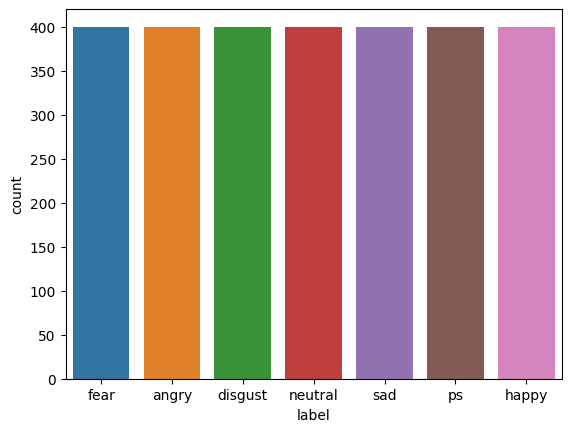

In [37]:
sns.countplot(data=df,x='label')

In [38]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()
    
def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

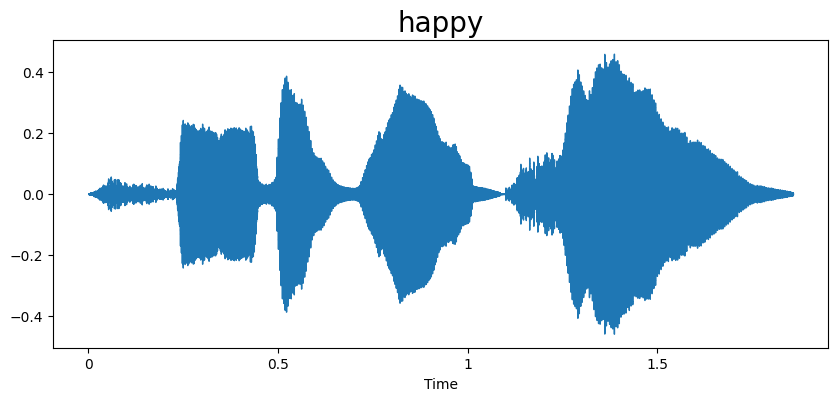

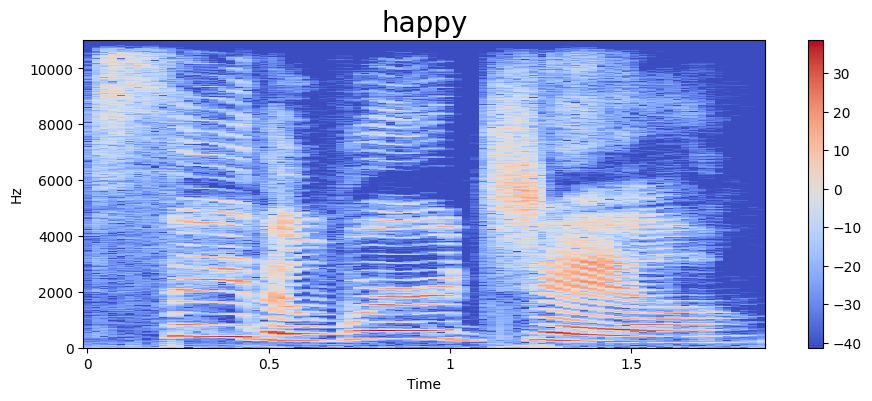

In [39]:
emotion='happy'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

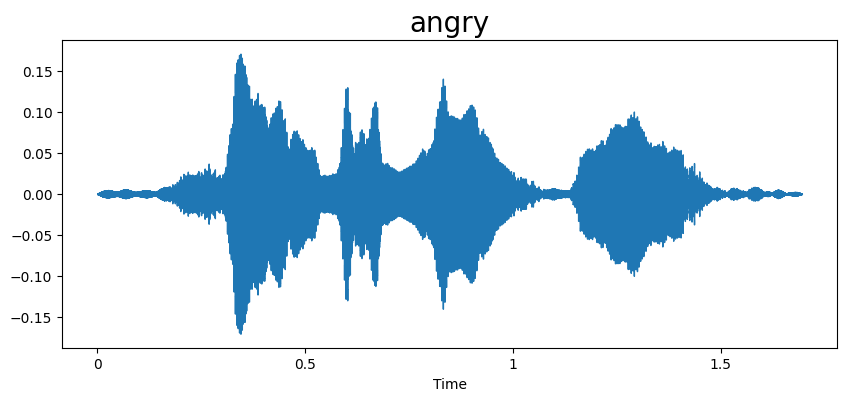

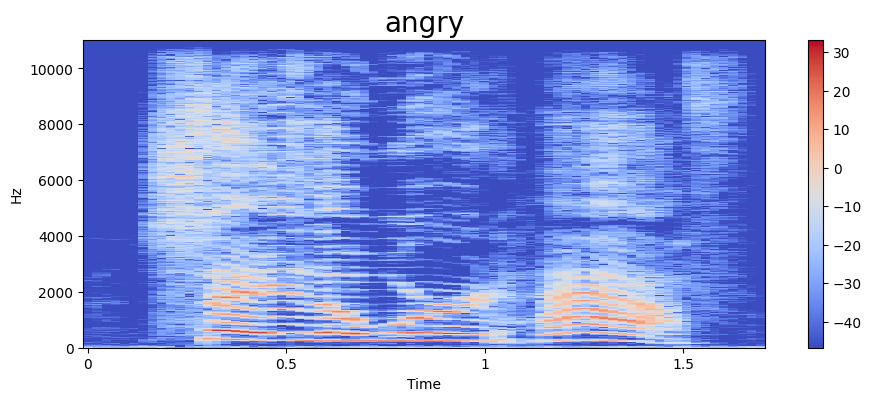

In [40]:
emotion = 'angry'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

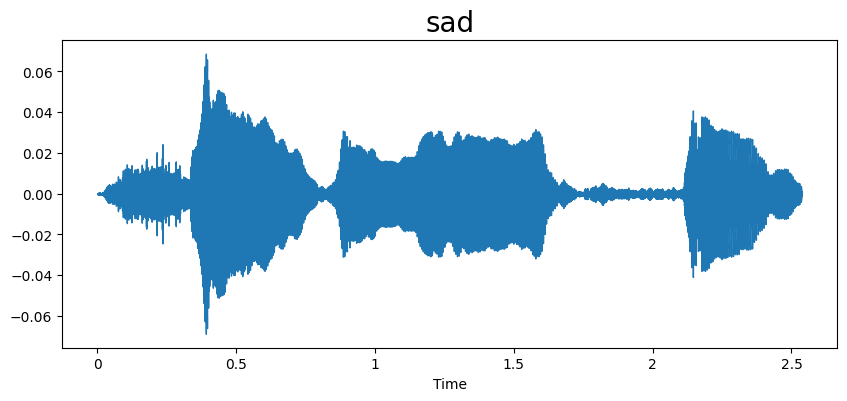

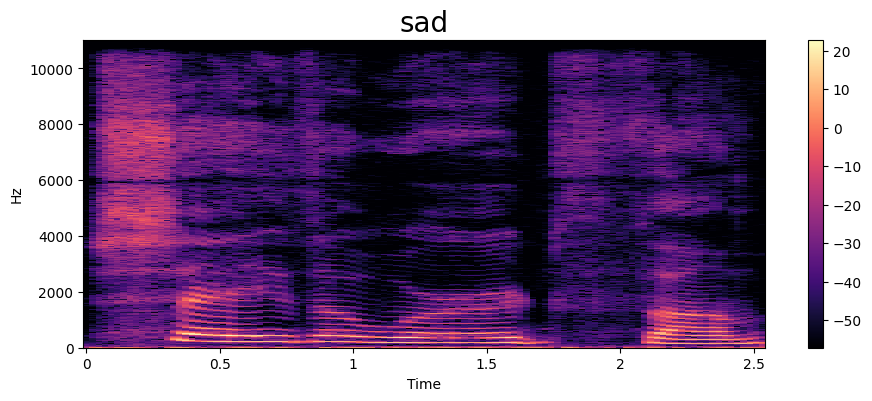

In [41]:
emotion = 'sad'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

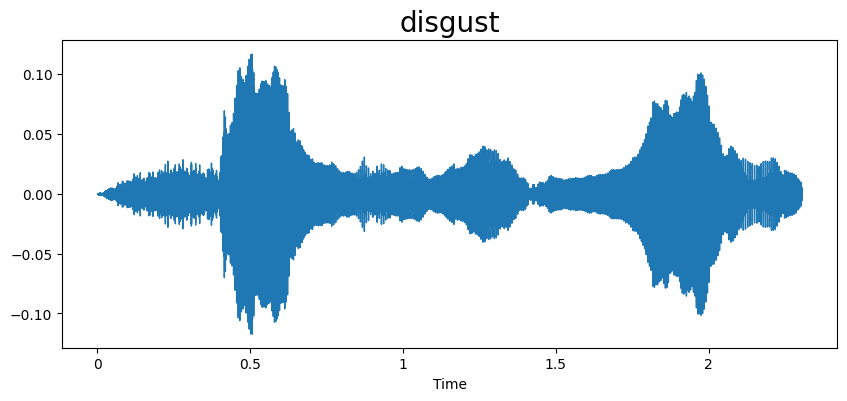

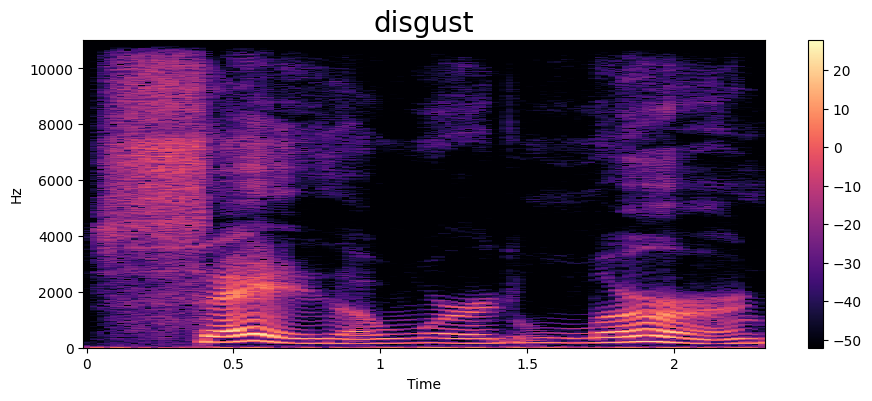

In [42]:
emotion = 'disgust'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

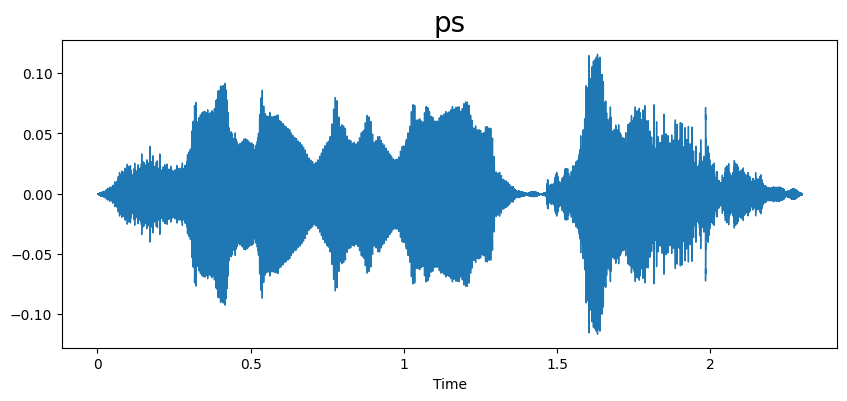

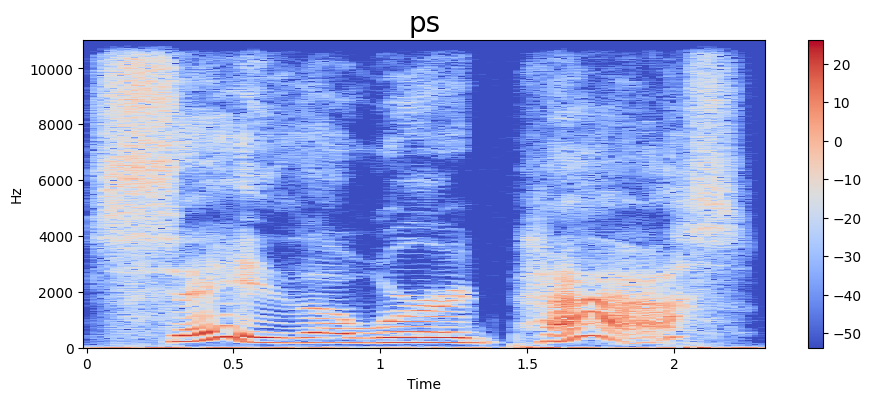

In [43]:
emotion = 'ps'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

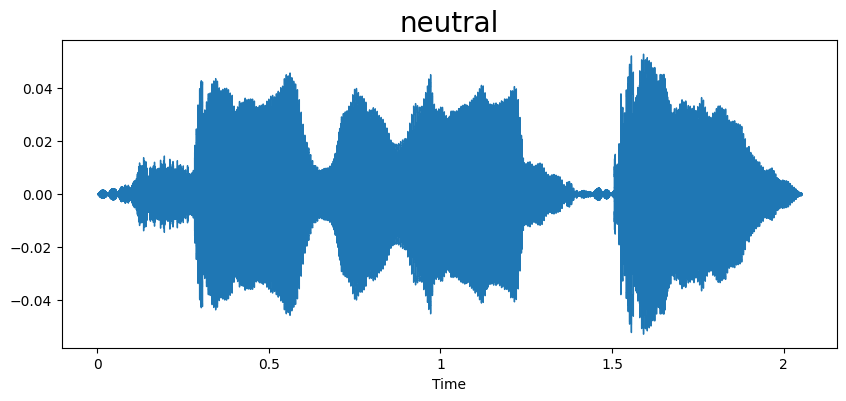

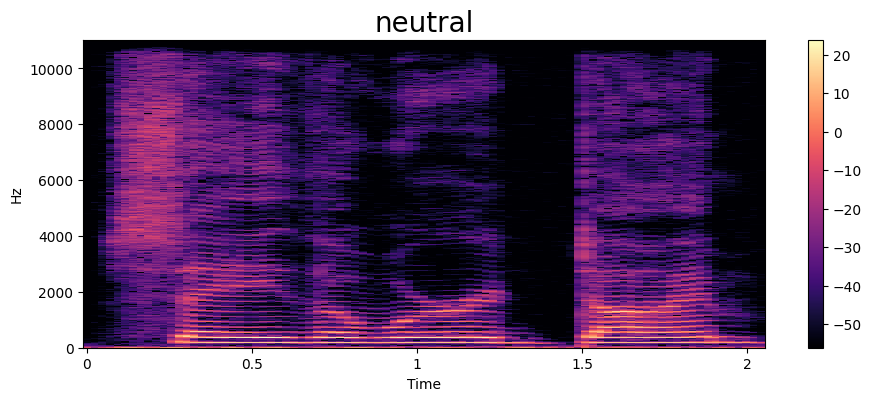

In [44]:
emotion = 'neutral'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

In [45]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

In [46]:
extract_mfcc(df['speech'][0])

array([-285.73727  ,   85.78295  ,   -2.1689112,   22.125532 ,
        -14.757396 ,   11.051346 ,   12.41245  ,   -3.000262 ,
          1.0844992,   11.078272 ,  -17.419659 ,   -8.093213 ,
          6.5879726,   -4.2209525,   -9.15508  ,    3.5214796,
        -13.186381 ,   14.078853 ,   19.66973  ,   22.725618 ,
         32.574635 ,   16.325033 ,   -3.8427296,    0.8962965,
        -11.239263 ,    6.653462 ,   -2.5883694,   -7.714016 ,
        -10.941657 ,   -2.4007545,   -5.2812867,    4.2711573,
        -11.202217 ,   -9.024621 ,   -3.6669843,    4.869744 ,
         -1.6027982,    2.5600514,   11.454374 ,   11.233449 ],
      dtype=float32)

In [47]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))

In [48]:
X_mfcc

0       [-285.73727, 85.78295, -2.1689112, 22.125532, ...
1       [-348.34332, 35.193233, -3.8413274, 14.658876,...
2       [-340.11435, 53.79644, -14.267782, 20.884027, ...
3       [-306.63422, 21.259705, -4.4110823, 6.4871554,...
4       [-344.7548, 46.329193, -24.171413, 19.392921, ...
                              ...                        
2795    [-374.3952, 60.864998, 0.025058484, 8.431059, ...
2796    [-313.96478, 39.847843, -5.6493053, -3.8675754...
2797    [-357.54883, 77.88606, -15.224756, 2.1946328, ...
2798    [-353.1474, 101.6839, -14.175897, -12.037376, ...
2799    [-389.4595, 54.042767, 1.3469975, -1.4258981, ...
Name: speech, Length: 2800, dtype: object

In [50]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(2800, 40)

In [53]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']])
y = y.toarray()

In [56]:
from sklearn.model_selection import train_test_split  # Correct import
# Split the dataset (80% train, 20% test by default)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [57]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(40,1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(7, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 256)                 │         264,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 307,655 (1.17 MB)

 Trainable params: 307,655 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.3859 - loss: 1.5284
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7865 - loss: 0.6050
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8662 - loss: 0.4139
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9300 - loss: 0.2459
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9416 - loss: 0.2142
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9457 - loss: 0.2005
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9524 - loss: 0.1636
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9606 - loss: 0.1402
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9480 - loss: 0.1469
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9595 - loss: 0.1309
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9656 - loss: 0.1290
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy:

In [60]:
y_pred=model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [68]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = np.argmax(y_pred, axis=1)

In [71]:
accuracy=accuracy_score(y_test,y_pred)*100
cf=confusion_matrix(y_test,y_pred)
print(f"accuracy: {accuracy}")
print(f"confusion matrix: {cf}")

accuracy: 96.96428571428571
confusion matrix: [[81  3  0  1  0  0  1]
 [ 0 72  0  1  0  1  0]
 [ 0  0 87  2  0  0  0]
 [ 0  0  0 78  0  5  0]
 [ 0  0  0  0 69  0  0]
 [ 0  1  0  2  0 67  0]
 [ 0  0  0  0  0  0 89]]


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


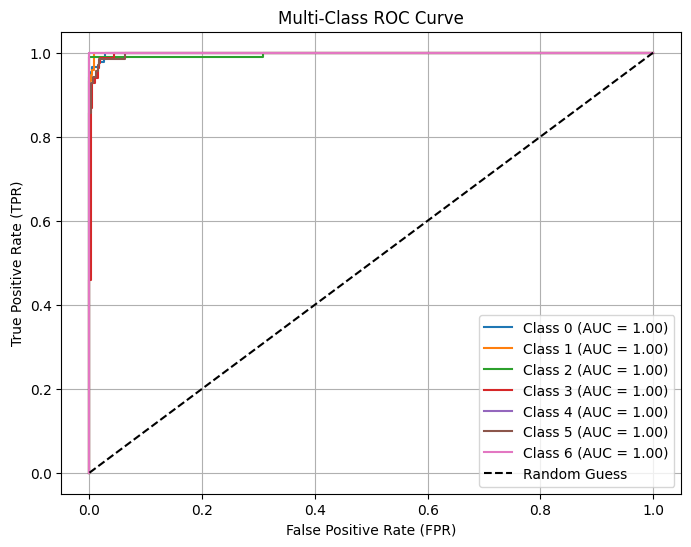

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Ensure y_test is one-hot encoded
if len(y_test.shape) == 1:  
    y_test = label_binarize(y_test, classes=np.unique(y_test))

# Use model.predict() instead of predict_proba()
y_pred = model.predict(X_test)  # ✅ Works for Keras models

# Get the number of classes
n_classes = y_test.shape[1]

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])  # Compute for class i
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Plot the diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [79]:
model.save('model.h5')